Environment: the `etunc` kernel (`envs/etunc.yml`, with the repo installed editable).

# Compare CMIP6 land fraction (sftlf) and build one 1° grid file

Kernel: `data-sci-py312`.

Not every CMIP6 model publishes `areacella` and `sftlf`, and some published `areacella` are wrong. All model
output is regridded to the common 1° grid (`rg.target_grid(1.0)`) anyway, so this notebook builds **one** cell
area and **one** land fraction for that grid, and checks how the models' native `sftlf` compare with it.

1. **Inventory**: which models in the ET catalog have `sftlf` / `areacella` (from `cmip6_all.csv`, since the
   ESGF-fetch catalog holds no `fx` files), and whether `sftlf` differs between a model's experiments/members.
2. **Native fields**: resolution, fractional vs binary coastlines, native land area, and checks of `areacella`
   against the exact spherical area of each grid.
3. **1° cell area** from the edges of `rg.target_grid(1.0)`.
4. **Regrid** every native `sftlf` conservatively to 1° (`rg.make_regridder`) and check that land area is conserved.
5. **Candidate 1° land fractions**: multi-model median, multi-model mean, and single high-resolution reference
   models. Two benchmarks are shown alongside: the median over *distinct* fields (models sharing a land mask
   counted once) and Natural Earth 1:10m land.
6. **Comparison** of every model against every candidate: maps, ensemble spread, mask agreement, zonal land area,
   land area totals, threshold sensitivity.
7. **Spatial averages** for three models of different native resolution: land-mean ET and LAI with native weights
   vs 1° weights.
8. **Write** `proc/grid/grid_1deg.nc` (cell area + candidate land fractions) and the per-model regridded `sftlf`.

ICON-ESM-LR is excluded from the 1° comparison (unstructured grid).

In [14]:
import hashlib
import warnings
from pathlib import Path

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import regionmask as regmask
import xarray as xr

import etunc.config as config
import etunc.grid as rg
import etunc.units as units
from etunc.load.cmip import CMIPESGFLoader

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200, "display.max_rows", 200, "display.max_columns", 30)

## Settings

In [65]:
EV_CATALOG = Path("/glade/derecho/scratch/bbuchovecky/cmip_intake_esgf_fetch/catalogs/cmip_evap.csv")  # models in the ET analysis
FX_CATALOG = Path("/glade/derecho/scratch/bbuchovecky/cmip_intake_esgf_fetch/catalogs/cmip6_fx_glade.csv")  # has the fx files (sftlf, areacella)
REGRID_ROOT = Path("/glade/campaign/univ/uwas0155/cmip6/regridded")      # output of regrid_cmip_esgf.py
OUT_DIR = Path("/glade/work/bbuchovecky/et_unc/proc/grid")

EXPERIMENT_ID = "piControl"  # preferred experiment for fx files (sftlf is fixed, so others are used if missing)
RES = 1.0
EARTH_RADIUS = 6.371e6        # [m] for the analytic cell areas
EXCLUDE = ["ICON-ESM-LR"]     # unstructured grid, not on the regular conservative path

# Single-model reference candidates: the three finest native grids with sftlf
REFERENCE_SIDS = ["EC-Earth3-Veg", "CNRM-CM6-1-HR", "HadGEM3-GC31-MM"]

# Models with sftlf units incorrectly labeled as % instead of fraction
SIDS_TO_CONVERT_LF = ["FGOALS-f3-L", "E3SM-1-0"]

# Spatial-average tests: coarse, medium and fine native grids
TEST_SIDS = ["CanESM5", "CESM2", "CNRM-CM6-1-HR"]
TEST_VARS = ["evspsbl", "lai"]
TIME_SLICE = slice("1995-01", "2014-12")

LF_THRESH = config.LF_THRESH * 100  # [%] binary land mask threshold used by the binning pipeline
N_CONSISTENCY = 10              # sftlf files per model compared against the chosen one

# Candidate written as `sftlf` in grid_1deg.nc. None until it has been chosen from the comparison below;
# set to e.g. "median" and re-run the last section.
SFTLF_CHOICE = None

GRID = rg.target_grid(RES)
SPHERE = 4 * np.pi * EARTH_RADIUS**2

# Categorical series colors in fixed order (dataviz reference palette); maps use single-hue / diverging cmaps
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]

## Helpers

In [8]:
def cell_area(lat_b: np.ndarray, lon_b: np.ndarray, radius: float = EARTH_RADIUS) -> np.ndarray:
    """Exact spherical area [m2] of the cells of a lat/lon grid with 1-D edges, shape (lat, lon)."""
    dsin = np.diff(np.sin(np.deg2rad(lat_b)))
    dlon = np.deg2rad(np.diff(lon_b))
    return radius**2 * np.outer(dsin, dlon)


def coord_edges(ds: xr.Dataset, name: str) -> tuple[np.ndarray, str]:
    """
    Edges of the ascending 1-D coord `name`: the file's bounds when they are contiguous, else midpoints
    between centers. (rg.cell_bounds needs regular spacing, which Gaussian grids do not have.)
    """
    centers = ds[name].values
    for bname in (ds[name].attrs.get("bounds"), f"{name}_bnds", f"{name}_bounds"):
        if bname and bname in ds:
            b = np.sort(ds[bname].values, axis=1)
            if b.ndim == 2 and np.allclose(b[1:, 0], b[:-1, 1]):
                return np.append(b[:, 0], b[-1, 1]), "file"
    mid = (centers[1:] + centers[:-1]) / 2
    return np.concatenate([[2 * centers[0] - mid[0]], mid, [2 * centers[-1] - mid[-1]]]), "midpoint"


def native_grid(ds: xr.Dataset) -> xr.Dataset:
    """Grid of `ds` (1-D lat ascending, lon) with edges for xESMF; outer lat edges set to +-90."""
    lat_b, lat_src = coord_edges(ds, "lat")
    lon_b, lon_src = coord_edges(ds, "lon")
    lat_b = np.clip(lat_b, -90, 90)
    lat_b[0], lat_b[-1] = -90, 90
    grid = xr.Dataset(coords={
        "lat": ("lat", ds["lat"].values), "lon": ("lon", ds["lon"].values),
        "lat_b": ("lat_b", lat_b), "lon_b": ("lon_b", lon_b),
    })
    grid.attrs["edges"] = lat_src if lat_src == lon_src else f"lat {lat_src}, lon {lon_src}"
    return grid


def grid_area(grid: xr.Dataset) -> xr.DataArray:
    """Analytic cell area [m2] of a grid with 1-D edges."""
    return xr.DataArray(cell_area(grid["lat_b"].values, grid["lon_b"].values), dims=("lat", "lon"),
                        coords={"lat": grid["lat"].values, "lon": grid["lon"].values})


def analysis_domain(da: xr.DataArray) -> xr.DataArray:
    """True inside the binning domain: config.LAT_BNDS and not Greenland/Iceland (AR6 land region 0)."""
    gic = regmask.defined_regions.ar6.land.mask(da["lon"], da["lat"]) == 0
    in_lat = (da["lat"] >= config.LAT_BNDS.start) & (da["lat"] <= config.LAT_BNDS.stop)
    return (in_lat & ~gic).transpose("lat", "lon")


def wmean(da: xr.DataArray, weights: xr.DataArray) -> float:
    """Weighted mean of `da` over its valid cells (weights renormalized where `da` is NaN)."""
    return float(da.weighted(weights.fillna(0)).mean(("lat", "lon"), skipna=True))


def land_area(lf: xr.DataArray, area: xr.DataArray, mask: xr.DataArray | bool = True) -> xr.DataArray:
    """Land area [Mkm2] = sum(area * lf/100) over `mask`."""
    return (area * lf / 100).where(mask).sum(("lat", "lon")) / 1e12


def map_facets(da: xr.DataArray, col: str, ncols: int = 3, title: str = "", panel_w: float = 4.6, **kwargs):
    """Facet of global maps (PlateCarree) of `da` along `col`, one shared colorbar."""
    kwargs.setdefault("cbar_kwargs", {"shrink": 0.6, "pad": 0.02})
    n = da.sizes[col]
    nrows = int(np.ceil(n / min(ncols, n)))
    p = da.plot.pcolormesh(
        col=col, col_wrap=min(ncols, n), transform=ccrs.PlateCarree(),
        subplot_kws={"projection": ccrs.PlateCarree()}, figsize=(panel_w * min(ncols, n), 0.6 * panel_w * nrows + 0.6),
        **kwargs,
    )
    for ax in p.axs.flat:
        ax.coastlines(lw=0.4, color="0.3")
    p.set_titles("{value}", size=9)
    if title:
        p.fig.suptitle(title, y=1.0)
    return p

## 1. Inventory

`cmip_evap.csv` (ESGF fetch) defines the models in the ET analysis but contains no `fx` files, so `sftlf` and
`areacella` come from `cmip6_fx_glade.csv`.

In [9]:
models = sorted(pd.read_csv(EV_CATALOG)["source_id"].unique())
fx = pd.read_csv(FX_CATALOG, low_memory=False)
fx = fx[fx["variable_id"].isin(["sftlf", "areacella"]) & fx["source_id"].isin(models)]


def fx_files(sid: str, var: str) -> pd.DataFrame:
    rows = fx[(fx["source_id"] == sid) & (fx["variable_id"] == var)]
    return (rows.assign(_other_exp=rows["experiment_id"] != EXPERIMENT_ID)
            .sort_values(["_other_exp", "member_id", "path"]).drop(columns="_other_exp"))


inventory = pd.DataFrame([
    {
        "source_id": sid,
        "n_sftlf_files": len(fx_files(sid, "sftlf")),
        "n_areacella_files": len(fx_files(sid, "areacella")),
        "sftlf_experiment": fx_files(sid, "sftlf")["experiment_id"].iloc[0] if len(fx_files(sid, "sftlf")) else "",
        "grid_label": fx_files(sid, "sftlf")["grid_label"].iloc[0] if len(fx_files(sid, "sftlf")) else "",
    }
    for sid in models
]).set_index("source_id")

print(f"{len(models)} models in the ET catalog")
print(f"  with sftlf:    {(inventory.n_sftlf_files > 0).sum()}")
print(f"  with areacella: {(inventory.n_areacella_files > 0).sum()}")
print(f"  no sftlf:      {inventory.index[inventory.n_sftlf_files == 0].tolist()}")
print(f"  sftlf only from a non-{EXPERIMENT_ID} experiment: "
      f"{inventory.index[(inventory.n_sftlf_files > 0) & (inventory.sftlf_experiment != EXPERIMENT_ID)].tolist()}")

74 models in the ET catalog
  with sftlf:    58
  with areacella: 36
  no sftlf:      ['AWI-ESM-1-REcoM', 'BCC-CSM2-MR', 'CAS-ESM2-0', 'CIESM', 'CMCC-CM2-HR4', 'EC-Earth3-CC', 'EC-Earth3-HR', 'FIO-ESM-2-0', 'GISS-E2-2-H', 'IITM-ESM', 'IPSL-CM5A2-INCA', 'IPSL-CM6A-LR-INCA', 'KACE-1-0-G', 'KIOST-ESM', 'MCM-UA-1-0', 'UKESM1-1-LL']
  sftlf only from a non-piControl experiment: ['BCC-ESM1', 'CAMS-CSM1-0', 'FGOALS-f3-L', 'GFDL-ESM4', 'INM-CM5-0', 'NESM3']


In [72]:
inventory

,n_sftlf_files,n_areacella_files,sftlf_experiment,grid_label
source_id,,,,
ACCESS-CM2,1,1,piControl,gn
ACCESS-ESM1-5,1,1,piControl,gn
AWI-CM-1-1-MR,1,0,piControl,gn
AWI-ESM-1-1-LR,1,1,piControl,gn
AWI-ESM-1-REcoM,0,0,,
BCC-CSM2-MR,0,0,,
BCC-ESM1,1,1,1pctCO2,gn
CAMS-CSM1-0,1,1,1pctCO2,gn
CAS-ESM2-0,0,0,,


## 2. Native fields

Each model's `sftlf` is put on ascending lat. Its `areacella` is used only when it is on the same grid.
`area_ratio` is `sum(areacella) / 4πR²` with R = 6371 km; `implied_R_km` is the radius that sum implies.
A ratio far from 1 means a broken `areacella`. `native_land_Mkm2` uses the analytic area of the native cells
(edges from the file's bounds, else midpoints), so it does not depend on `areacella`.

In [55]:
native: dict[str, xr.DataArray] = {}   # sid -> sftlf [%] on its native grid
native_area: dict[str, xr.DataArray] = {}   # sid -> areacella [m2], where it matches the sftlf grid
grids: dict[str, xr.Dataset] = {}
rows = []

for sid in models:
    files = fx_files(sid, "sftlf")
    if files.empty or sid in EXCLUDE:
        continue
    ds = xr.open_dataset(files["path"].iloc[0])
    if "lat" not in ds["sftlf"].dims:
        print(f"{sid}: skipped, not on a lat/lon grid {dict(ds['sftlf'].sizes)}")
        continue
    ds = ds.sortby("lat")
    lf = ds["sftlf"].reset_coords(drop=True).load()  # some files carry scalar coords (e.g. `type`)
    if lf.attrs.get("units") != "%" or sid in SIDS_TO_CONVERT_LF:
        print(f"{sid}: sftlf units {lf.attrs.get('units')!r}, converted to %")
        lf = lf * 100
    native[sid] = lf
    grids[sid] = native_grid(ds)

    # sftlf consistency across this model's other files (experiments/members): distinct fields on the same grid
    n_checked, n_shifted, max_diff, fields = 0, 0, 0.0, {np.round(lf.values, 2).tobytes()}
    for path in files["path"].iloc[1:N_CONSISTENCY + 1]:
        other = xr.open_dataset(path)["sftlf"].sortby("lat")
        if other.shape != lf.shape:
            continue
        n_checked += 1
        if not (np.allclose(other["lat"], lf["lat"], atol=1e-3) and np.allclose(other["lon"], lf["lon"], atol=1e-3)):
            n_shifted += 1  # same shape, different coordinates: not comparable cell by cell
            continue
        fields.add(np.round(other.values, 2).tobytes())
        max_diff = max(max_diff, float(np.abs(other.values - lf.values).max()))

    # areacella on the same grid: the first file whose total is within 1% of the sphere, else the first match
    n_area_files, n_bad_area_files = 0, 0
    for path in fx_files(sid, "areacella")["path"]:
        a = xr.open_dataset(path)["areacella"]
        if "lat" not in a.dims or a.shape != lf.shape:
            continue
        a = a.sortby("lat").reset_coords(drop=True)
        if not (np.allclose(a["lat"], lf["lat"], atol=1e-3) and np.allclose(a["lon"], lf["lon"], atol=1e-3)):
            continue
        n_area_files += 1
        ok = abs(float(a.sum()) / SPHERE - 1) < 0.01
        n_bad_area_files += not ok
        if ok and (sid not in native_area or abs(float(native_area[sid].sum()) / SPHERE - 1) >= 0.01):
            native_area[sid] = a.load().assign_coords(lat=lf["lat"], lon=lf["lon"])  # equal within 1e-3, not exactly
        elif sid not in native_area:
            native_area[sid] = a.load().assign_coords(lat=lf["lat"], lon=lf["lon"])

    exact = grid_area(grids[sid])
    a = native_area.get(sid)
    rows.append({
        "source_id": sid,
        "nlat": lf.sizes["lat"], "nlon": lf.sizes["lon"],
        "dlat": 180 / lf.sizes["lat"], "dlon": 360 / lf.sizes["lon"],
        "edges": grids[sid].attrs["edges"],
        "frac_partial_cells": float(((lf > 0) & (lf < 100)).mean()),
        "native_land_Mkm2": float(land_area(lf, exact)),
        "areacella_land_Mkm2": float(land_area(lf, a)) if a is not None else np.nan,
        "area_ratio": float(a.sum()) / SPHERE if a is not None else np.nan,
        "implied_R_km": np.sqrt(float(a.sum()) / (4 * np.pi)) / 1e3 if a is not None else np.nan,
        "max_rel_diff_areacella_vs_exact": float(np.abs(a.values / (exact.values * float(a.sum() / exact.sum())) - 1).max()) if a is not None else np.nan,
        "n_sftlf_checked": n_checked, "n_sftlf_distinct": len(fields), "n_sftlf_shifted": n_shifted,
        "max_sftlf_diff": max_diff, "n_areacella_files": n_area_files, "n_bad_areacella_files": n_bad_area_files,
    })

info = pd.DataFrame(rows).set_index("source_id")
sids = info.index.tolist()
info.round(4)

E3SM-1-0: sftlf units '%', converted to %
FGOALS-f3-L: sftlf units '%', converted to %


,nlat,nlon,dlat,dlon,edges,frac_partial_cells,native_land_Mkm2,areacella_land_Mkm2,area_ratio,implied_R_km,max_rel_diff_areacella_vs_exact,n_sftlf_checked,n_sftlf_distinct,n_sftlf_shifted,max_sftlf_diff,n_areacella_files,n_bad_areacella_files
source_id,,,,,,,,,,,,,,,,,
ACCESS-CM2,144,192,1.2500,1.8750,file,0.0879,148.7237,148.7314,1.0001,6371.2203,0.0002,0,1,0,0.0,1,0
ACCESS-ESM1-5,145,192,1.2414,1.8750,file,0.0874,148.7051,148.6614,0.9997,6370.0637,0.0000,0,1,0,0.0,1,0
AWI-CM-1-1-MR,192,384,0.9375,0.9375,file,0.0000,147.1899,NaN,NaN,NaN,NaN,0,1,0,0.0,0,0
AWI-ESM-1-1-LR,96,192,1.8750,1.8750,file,0.0000,144.6888,144.6864,1.0000,6370.9998,0.0002,0,1,0,0.0,1,0
BCC-ESM1,64,128,2.8125,2.8125,file,0.1620,149.7925,149.7823,1.0000,6371.0034,0.0547,0,1,0,0.0,1,0
CAMS-CSM1-0,160,320,1.1250,1.1250,file,0.0709,147.0684,147.0667,1.0000,6371.0000,0.0547,0,1,0,0.0,1,0
CESM2,192,288,0.9375,1.2500,file,0.0674,149.4381,149.4484,1.0001,6371.2201,0.0006,0,1,0,0.0,1,0
CESM2-FV2,96,144,1.8750,2.5000,file,0.1215,149.4413,149.4516,1.0001,6371.2201,0.0000,0,1,0,0.0,1,0
CESM2-WACCM,192,288,0.9375,1.2500,file,0.0674,149.4381,149.4484,1.0001,6371.2201,0.0006,0,1,0,0.0,1,0


`max_rel_diff_areacella_vs_exact` compares the *shape* of `areacella` with the analytic area (after scaling to the
same total), so it isolates layout problems from the choice of radius.

Models whose `areacella` should not be trusted, models with binary (0/100) coastlines, and models whose `sftlf` differs
between files. A model's chosen `areacella` is a file on the `sftlf` grid whose total is within 1% of the sphere, when one
exists.

In [57]:
bad_area = info.index[(info.area_ratio - 1).abs() > 1e-3].tolist()
no_area = info.index[info.area_ratio.isna()].tolist()
binary = info.index[info.frac_partial_cells == 0].tolist()
inconsistent = info[(info.n_sftlf_distinct > 1) | (info.n_sftlf_shifted > 0)][
    ["n_sftlf_checked", "n_sftlf_distinct", "max_sftlf_diff", "n_sftlf_shifted"]]

# Also check areacella of models without (usable) sftlf
extra = []
for sid in sorted(set(models) - set(sids)):
    for path in fx_files(sid, "areacella")["path"][:1]:
        a = xr.open_dataset(path)["areacella"]
        extra.append((sid, float(a.sum()) / SPHERE))

print(f"areacella used here off by > 0.1%: {bad_area}")
print(f"models with at least one bad areacella file (> 1% off): {info.index[info.n_bad_areacella_files > 0].tolist()}")
print(f"  ... and among models without sftlf: {[(s, round(r, 4)) for s, r in extra if abs(r - 1) > 1e-3]}")
print(f"no areacella on the sftlf grid: {no_area}")
print(f"binary sftlf (no partial cells): {binary}")
print(f"radius implied by areacella [km]: {sorted(info.implied_R_km.dropna().round(2).unique())}")
print(f"\nsftlf differs between a model's files (up to {N_CONSISTENCY} other files checked; "
      "shifted = same shape but different lat/lon):")
print(inconsistent if len(inconsistent) else "  none")

areacella used here off by > 0.1%: []
models with at least one bad areacella file (> 1% off): []
  ... and among models without sftlf: [('MCM-UA-1-0', 0.01)]
no areacella on the sftlf grid: ['AWI-CM-1-1-MR', 'CMCC-CM2-SR5', 'CMCC-ESM2', 'CanESM5-1', 'E3SM-1-1', 'E3SM-1-1-ECA', 'E3SM-2-0', 'E3SM-2-0-NARRM', 'E3SM-2-1', 'EC-Earth3', 'EC-Earth3-AerChem', 'EC-Earth3-ESM-1', 'EC-Earth3-Veg', 'EC-Earth3-Veg-LR', 'FGOALS-f3-L', 'FGOALS-g3', 'GISS-E2-1-G-CC', 'GISS-E2-2-G', 'GISS-E3-G', 'MIROC-ES2H', 'NESM3', 'NorCPM1']
binary sftlf (no partial cells): ['AWI-CM-1-1-MR', 'AWI-ESM-1-1-LR', 'INM-CM4-8', 'INM-CM5-0', 'MPI-ESM-1-2-HAM', 'MPI-ESM1-2-HR', 'MPI-ESM1-2-LR']
radius implied by areacella [km]: [np.float64(6370.0), np.float64(6370.06), np.float64(6371.0), np.float64(6371.02), np.float64(6371.09), np.float64(6371.22), np.float64(6371.23), np.float64(6371.25)]

sftlf differs between a model's files (up to 10 other files checked; shifted = same shape but different lat/lon):
  none


Several models share a land mask (same grid and same field), so a plain multi-model statistic gives a model family more
weight. Groups of identical native fields:

In [58]:
def field_hash(da: xr.DataArray) -> str:
    return hashlib.sha1(np.round(da.values, 2).tobytes() + str(da.shape).encode()).hexdigest()[:10]


info["field_id"] = [field_hash(native[s]) for s in sids]
groups = info.groupby("field_id").apply(lambda g: g.index.tolist())
for members in groups[groups.map(len) > 1]:
    print(members)
unique_sids = info.reset_index().groupby("field_id")["source_id"].first().sort_values().tolist()
print(f"\n{len(sids)} models, {len(unique_sids)} distinct native sftlf fields")

['HadGEM3-GC31-LL', 'UKESM1-0-LL']
['E3SM-1-0', 'E3SM-1-1', 'E3SM-1-1-ECA']
['CESM2', 'CESM2-WACCM']
['EC-Earth3', 'EC-Earth3-AerChem', 'EC-Earth3-Veg']
['SAM0-UNICON', 'TaiESM1']
['MPI-ESM-1-2-HAM', 'MPI-ESM1-2-LR']
['MIROC-ES2H', 'MIROC-ES2L']
['CMCC-CM2-SR5', 'CMCC-ESM2']
['GISS-E2-1-G', 'GISS-E2-1-H', 'GISS-E2-2-G']
['CESM2-FV2', 'CESM2-WACCM-FV2']
['CanESM5', 'CanESM5-CanOE']
['INM-CM4-8', 'INM-CM5-0']
['E3SM-2-0', 'E3SM-2-1']

57 models, 41 distinct native sftlf fields


## 3. Cell area of the 1° grid

Exact spherical area from the cell edges of `rg.target_grid(1.0)` with R = 6371 km. E3SM's native grid is the same
1° grid in 0–360 longitude, so its `areacella` is an independent check (E3SM uses R = 6371.22 km).

In [59]:
area = grid_area(GRID).assign_coords(lat=GRID["lat"], lon=GRID["lon"])
area.attrs = {"standard_name": "cell_area", "long_name": "grid cell area", "units": "m2",
              "comment": f"exact spherical area from the cell edges of regrid.target_grid({RES}), R = {EARTH_RADIUS:.0f} m"}
print(f"sum(area) / 4 pi R^2 = {float(area.sum()) / SPHERE:.12f}")

e3sm = native_area["E3SM-1-0"].assign_coords(lon=((native_area["E3SM-1-0"]["lon"] + 180) % 360) - 180).sortby("lon")
e3sm_scaled = e3sm * (EARTH_RADIUS / 6.37122e6) ** 2
rel = (e3sm_scaled.values / area.values) - 1
print(f"E3SM-1-0 areacella (rescaled to R = 6371 km) vs analytic: max |rel diff| = {np.abs(rel).max():.2e}")

sum(area) / 4 pi R^2 = 1.000000000000
E3SM-1-0 areacella (rescaled to R = 6371 km) vs analytic: max |rel diff| = 5.08e-05


## 4. Regrid native sftlf to 1°

First-order conservative (`rg.make_regridder(..., "conservative")`) from each native grid. Land area should be
conserved: `d_land_pct` compares 1° land area with native land area, both from analytic cell areas.

In [60]:
regridders = {}
lf_1deg = []
for sid in sids:
    regridders[sid] = rg.make_regridder(grids[sid], RES, "conservative")
    lf_1deg.append(regridders[sid](native[sid]).clip(0, 100))

lf = xr.concat(lf_1deg, dim=pd.Index(sids, name="source_id")).assign_coords(lat=GRID["lat"], lon=GRID["lon"])
lf.attrs = {"long_name": "land area fraction, conservatively regridded from each model's native sftlf", "units": "%"}

domain = analysis_domain(area)
info["land_Mkm2"] = land_area(lf, area).to_series()
info["d_land_pct"] = 100 * (info.land_Mkm2 / info.native_land_Mkm2 - 1)
info["land_domain_Mkm2"] = land_area(lf, area, domain).to_series()
print(f"max |d_land_pct| = {info.d_land_pct.abs().max():.2e} %")
info[["dlat", "dlon", "native_land_Mkm2", "land_Mkm2", "d_land_pct", "land_domain_Mkm2"]].sort_values("land_Mkm2").round(3)

max |d_land_pct| = 3.24e-03 %


,dlat,dlon,native_land_Mkm2,land_Mkm2,d_land_pct,land_domain_Mkm2
source_id,,,,,,
NorESM2-LM,1.875,2.500,144.553,144.550,-0.002,129.984
AWI-ESM-1-1-LR,1.875,1.875,144.689,144.687,-0.001,129.056
GISS-E2-1-G-CC,2.000,2.500,144.919,144.915,-0.002,128.535
GISS-E3-G,1.000,1.250,144.992,144.992,-0.000,128.606
IPSL-CM6A-LR,1.259,2.500,146.534,146.530,-0.002,130.377
CNRM-ESM2-1,1.406,1.406,146.588,146.587,-0.000,130.979
CMCC-ESM2,0.938,1.250,146.769,146.768,-0.000,130.594
CMCC-CM2-SR5,0.938,1.250,146.769,146.768,-0.000,130.594
CanESM5-1,2.812,2.812,146.804,146.799,-0.003,130.581


## 5. Candidate 1° land fractions

* `median`, `mean`: per-cell statistic over all regridded models.
* `ref_<model>`: one model's regridded field, for the three finest native grids.

Benchmarks (not candidates): `median_unique` (median over distinct fields, so a family that shares a land mask counts once)
and `natural_earth` (fractional overlap of the Natural Earth 1:10m land polygons, `regionmask.mask_3D_frac_approx`;
lakes are land except the Caspian, as in the CMIP6 `sftlf` definition).

In [73]:
candidates = {
    "median": lf.median("source_id"),
    "mean": lf.mean("source_id"),
    **{f"ref_{s}": lf.sel(source_id=s, drop=True) for s in REFERENCE_SIDS},
}
ne = regmask.defined_regions.natural_earth_v5_1_2.land_10.mask_3D_frac_approx(GRID["lon"], GRID["lat"]).sum("region")
benchmarks = {
    "median_unique": lf.sel(source_id=unique_sids).median("source_id"),
    "natural_earth": (100 * ne).clip(0, 100).drop_vars([c for c in ne.coords if c not in ("lat", "lon")]),
}
compare = {**candidates, **benchmarks}
cand = xr.concat(list(compare.values()), dim=pd.Index(list(compare), name="candidate"))
colors = dict(zip(compare, SERIES))

summary = pd.DataFrame({
    "land_Mkm2": land_area(cand, area).to_series(),
    "land_domain_Mkm2": land_area(cand, area, domain).to_series(),
    f"mask_area_Mkm2 (>{LF_THRESH:.0f}%)": (area.where(cand > LF_THRESH).sum(("lat", "lon")) / 1e12).to_series(),
    "n_partial_cells": ((cand > 0) & (cand < 100)).sum(("lat", "lon")).to_series(),
})
print(f"Model land area: median {info.land_Mkm2.median():.2f}, mean {info.land_Mkm2.mean():.2f}, "
      f"range {info.land_Mkm2.min():.2f}-{info.land_Mkm2.max():.2f} Mkm2")
summary.round(2)

Model land area: median 148.81, mean 148.70, range 144.55-155.97 Mkm2


,land_Mkm2,land_domain_Mkm2,mask_area_Mkm2 (>50%),n_partial_cells
candidate,,,,
median,148.71,132.52,147.69,8784
mean,148.70,132.57,147.74,28957
ref_EC-Earth3-Veg,147.38,131.16,146.85,5536
ref_CNRM-CM6-1-HR,149.31,133.13,148.22,8294
ref_HadGEM3-GC31-MM,148.49,132.30,147.40,8621
median_unique,148.67,132.52,147.62,9076
natural_earth,146.74,132.17,145.87,6079


Note: the per-cell median is not land-area conserving, so its total need not equal the median of the model totals.

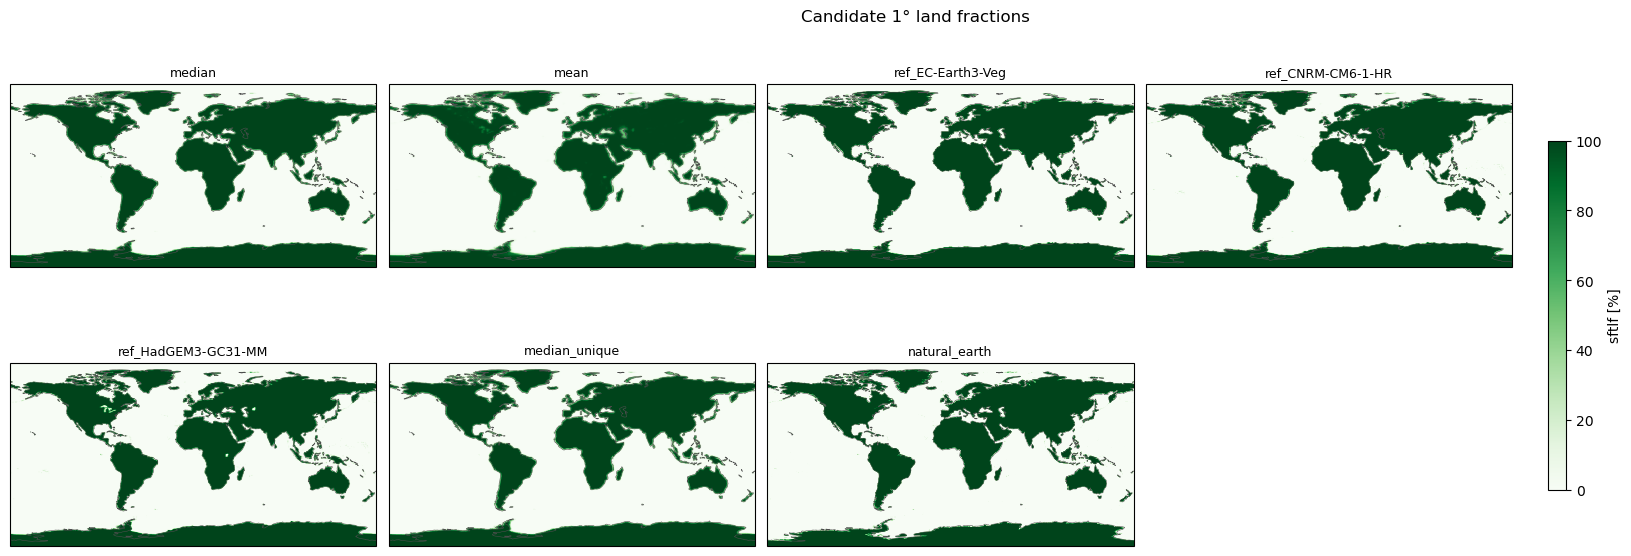

In [74]:
map_facets(cand, "candidate", ncols=4, cmap="Greens", vmin=0, vmax=100,
           cbar_kwargs={"label": "sftlf [%]", "shrink": 0.6, "pad": 0.02}, title="Candidate 1° land fractions");

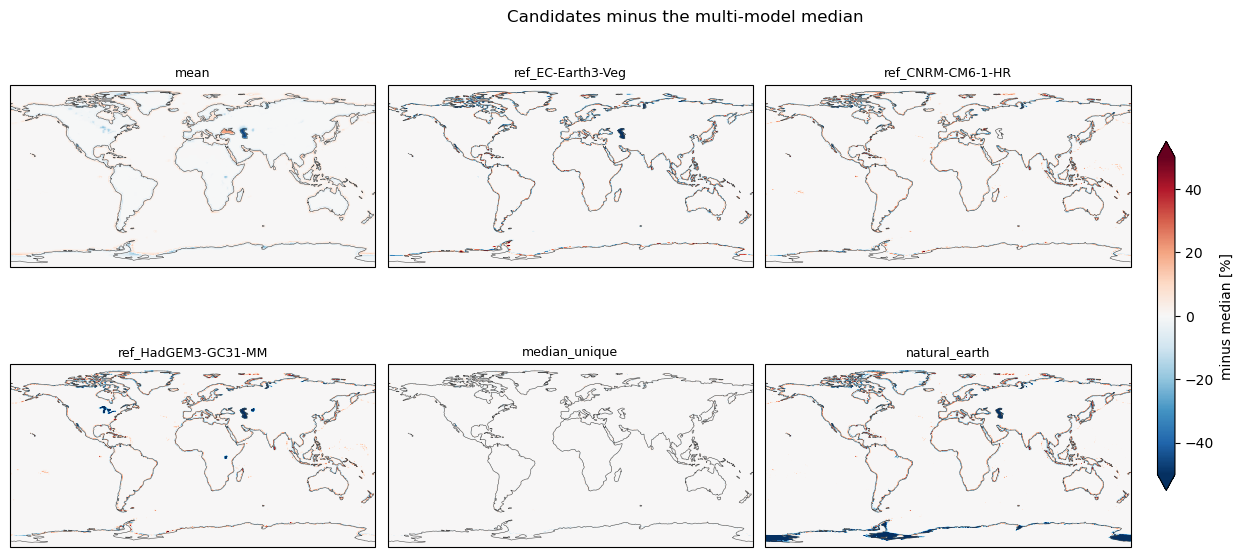

In [75]:
diff = (cand - cand.sel(candidate="median")).drop_sel(candidate="median")
map_facets(diff, "candidate", ncols=3, cmap="RdBu_r", vmin=-50, vmax=50,
           cbar_kwargs={"label": "minus median [%]", "shrink": 0.6, "pad": 0.02}, title="Candidates minus the multi-model median");

## 6. How the models differ

### Ensemble spread on the 1° grid

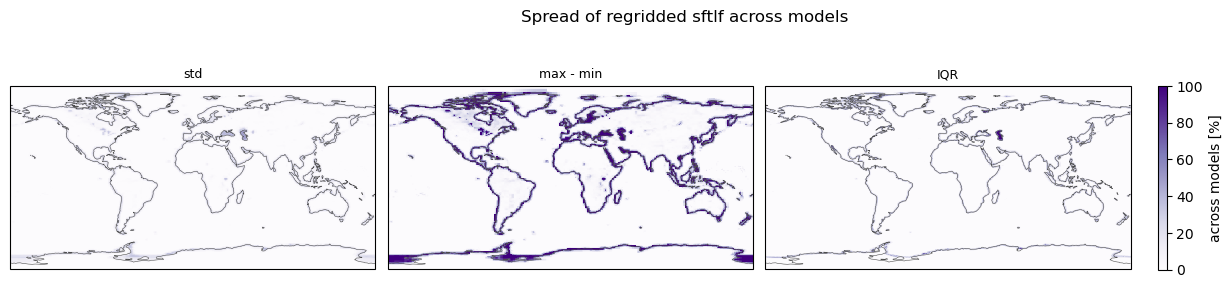

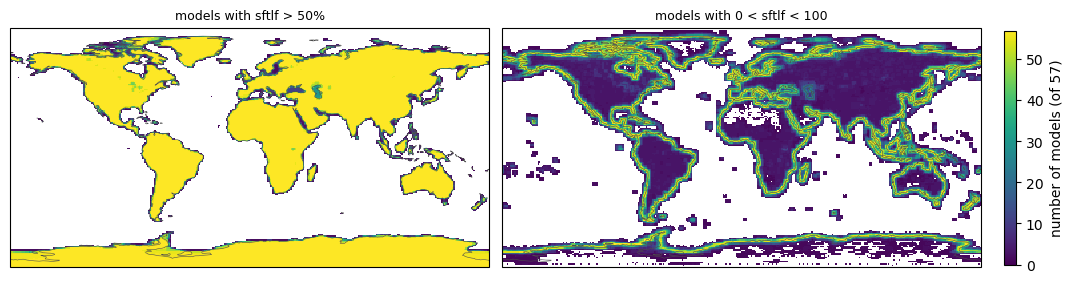

In [76]:
spread = xr.concat([
    lf.std("source_id"),
    lf.max("source_id") - lf.min("source_id"),
    lf.quantile(0.75, "source_id") - lf.quantile(0.25, "source_id"),
], dim=pd.Index(["std", "max - min", "IQR"], name="stat")).drop_vars("quantile", errors="ignore")
map_facets(spread, "stat", ncols=3, cmap="Purples", vmin=0, vmax=100,
           cbar_kwargs={"label": "across models [%]", "shrink": 0.6, "pad": 0.02}, title="Spread of regridded sftlf across models");

n_land = (lf > LF_THRESH).sum("source_id")
agree = xr.concat([n_land, ((lf > 0) & (lf < 100)).sum("source_id")],
                  dim=pd.Index([f"models with sftlf > {LF_THRESH:.0f}%", "models with 0 < sftlf < 100"], name="count"))
map_facets(agree.where(agree > 0), "count", ncols=2, cmap="viridis", vmin=0, vmax=len(sids), panel_w=6,
           cbar_kwargs={"label": f"number of models (of {len(sids)})", "shrink": 0.6, "pad": 0.02});

In [77]:
contested = (n_land > 0) & (n_land < len(sids))
print(f"Cells where models disagree on land (> {LF_THRESH:.0f}%) vs not: {int(contested.sum())} "
      f"({float(area.where(contested).sum()) / 1e12:.2f} Mkm2; in domain {float(area.where(contested & domain).sum()) / 1e12:.2f} Mkm2)")
print(f"Cells that every model calls land: {int((n_land == len(sids)).sum())} ({float(area.where(n_land == len(sids)).sum()) / 1e12:.2f} Mkm2)")

Cells where models disagree on land (> 50%) vs not: 6589 (46.68 Mkm2; in domain 41.49 Mkm2)
Cells that every model calls land: 18675 (125.22 Mkm2)


### Each model minus the multi-model median

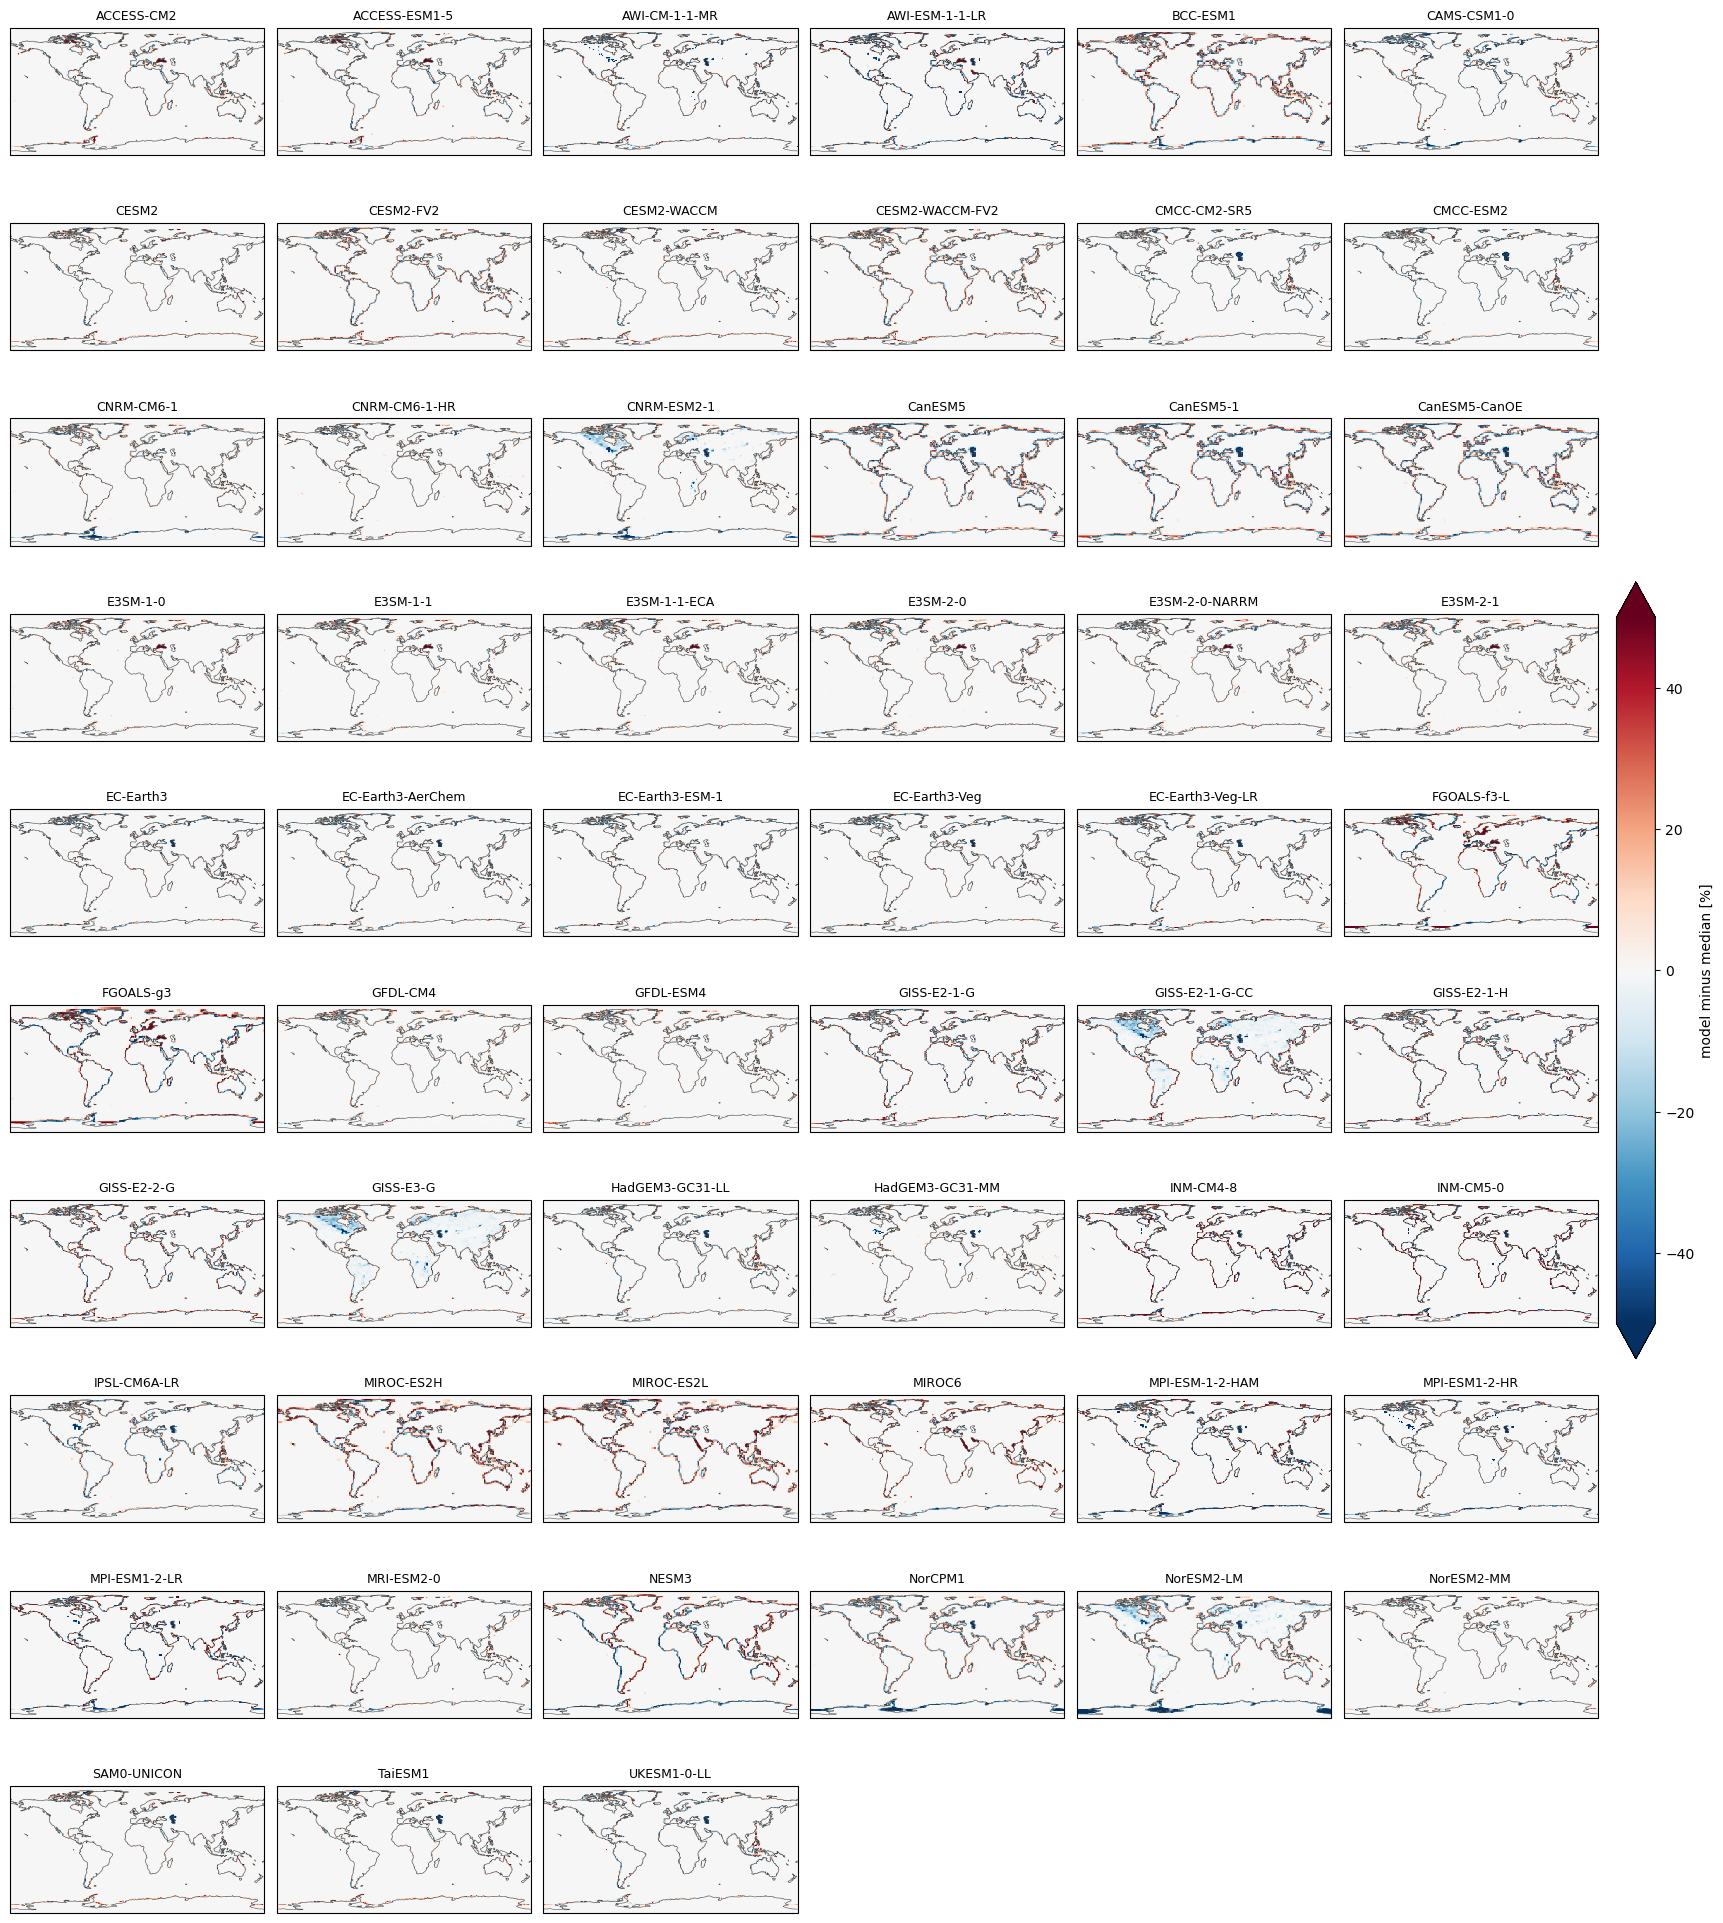

In [78]:
map_facets((lf - candidates["median"]), "source_id", ncols=6, panel_w=3.2, cmap="RdBu_r", vmin=-50, vmax=50,
           add_colorbar=True, cbar_kwargs={"label": "model minus median [%]", "shrink": 0.4, "pad": 0.01});

### Metrics of every model against every candidate

* `d_land_pct`, `d_land_domain_pct`: land area difference, globally and in the binning domain (`be.LAT_BNDS`, no Greenland/Iceland).
* `rmse`: area-weighted RMS difference of `sftlf` [%] over cells where either field is > 0.
* `mask_mismatch_Mkm2`: area in the domain where the binary masks (> `LF_THRESH`) disagree.
* `iou`: intersection over union of the two binary masks in the domain.

In [79]:
def metrics(lf_m: xr.DataArray, lf_c: xr.DataArray) -> dict:
    m, c = lf_m > LF_THRESH, lf_c > LF_THRESH
    either = (lf_m > 0) | (lf_c > 0)
    return {
        "d_land_pct": 100 * (float(land_area(lf_m, area)) / float(land_area(lf_c, area)) - 1),
        "d_land_domain_pct": 100 * (float(land_area(lf_m, area, domain)) / float(land_area(lf_c, area, domain)) - 1),
        "rmse": float(np.sqrt(((lf_m - lf_c) ** 2).weighted(area.where(either, 0)).mean())),
        "mask_mismatch_Mkm2": float(area.where((m != c) & domain).sum()) / 1e12,
        "iou": float(area.where(m & c & domain).sum() / area.where((m | c) & domain).sum()),
    }


scores = pd.DataFrame([
    {"source_id": sid, "candidate": name, **metrics(lf.sel(source_id=sid), compare[name])}
    for sid in sids for name in compare
]).set_index(["candidate", "source_id"])

# Mean over models: how well each candidate represents the ensemble
ens_summary = scores.groupby("candidate").agg(
    mean_abs_d_land_pct=("d_land_pct", lambda x: x.abs().mean()),
    mean_rmse=("rmse", "mean"),
    mean_mask_mismatch_Mkm2=("mask_mismatch_Mkm2", "mean"),
    mean_iou=("iou", "mean"),
).loc[list(compare)]
ens_summary.round(3)

,mean_abs_d_land_pct,mean_rmse,mean_mask_mismatch_Mkm2,mean_iou
candidate,,,,
median,1.161,10.559,6.806,0.950
mean,1.162,9.007,6.891,0.949
ref_EC-Earth3-Veg,1.318,13.005,8.171,0.940
ref_CNRM-CM6-1-HR,1.203,12.183,7.741,0.943
ref_HadGEM3-GC31-MM,1.178,12.462,8.036,0.941
median_unique,1.164,10.509,6.820,0.950
natural_earth,1.533,15.243,8.071,0.941


The reference-model rows include the reference itself (zero difference), which favors them slightly. Per model, against
the median and Natural Earth:

In [80]:
scores.loc["median"].join(scores.loc["natural_earth"], rsuffix="_vs_NE").sort_values("rmse").round(3)

,d_land_pct,d_land_domain_pct,rmse,mask_mismatch_Mkm2,iou,d_land_pct_vs_NE,d_land_domain_pct_vs_NE,rmse_vs_NE,mask_mismatch_Mkm2_vs_NE,iou_vs_NE
source_id,,,,,,,,,,
GFDL-CM4,0.567,0.613,4.952,3.031,0.977,1.921,0.880,10.924,4.224,0.968
GFDL-ESM4,0.635,0.669,5.185,3.272,0.976,1.990,0.937,11.335,4.616,0.966
CESM2-WACCM,0.488,0.283,6.152,3.475,0.974,1.841,0.549,13.394,5.405,0.960
CESM2,0.488,0.283,6.152,3.475,0.974,1.841,0.549,13.394,5.405,0.960
MRI-ESM2-0,0.229,0.311,6.292,3.864,0.971,1.578,0.577,11.977,4.457,0.967
NorESM2-MM,0.675,0.885,6.369,3.563,0.973,2.031,1.152,12.181,4.341,0.968
CNRM-CM6-1-HR,0.402,0.458,6.604,3.209,0.976,1.753,0.725,9.490,1.747,0.987
CNRM-CM6-1,-0.089,0.340,6.633,3.791,0.972,1.256,0.607,11.576,5.939,0.956
E3SM-1-1,0.801,0.855,6.789,3.647,0.973,2.158,1.123,13.132,5.455,0.959


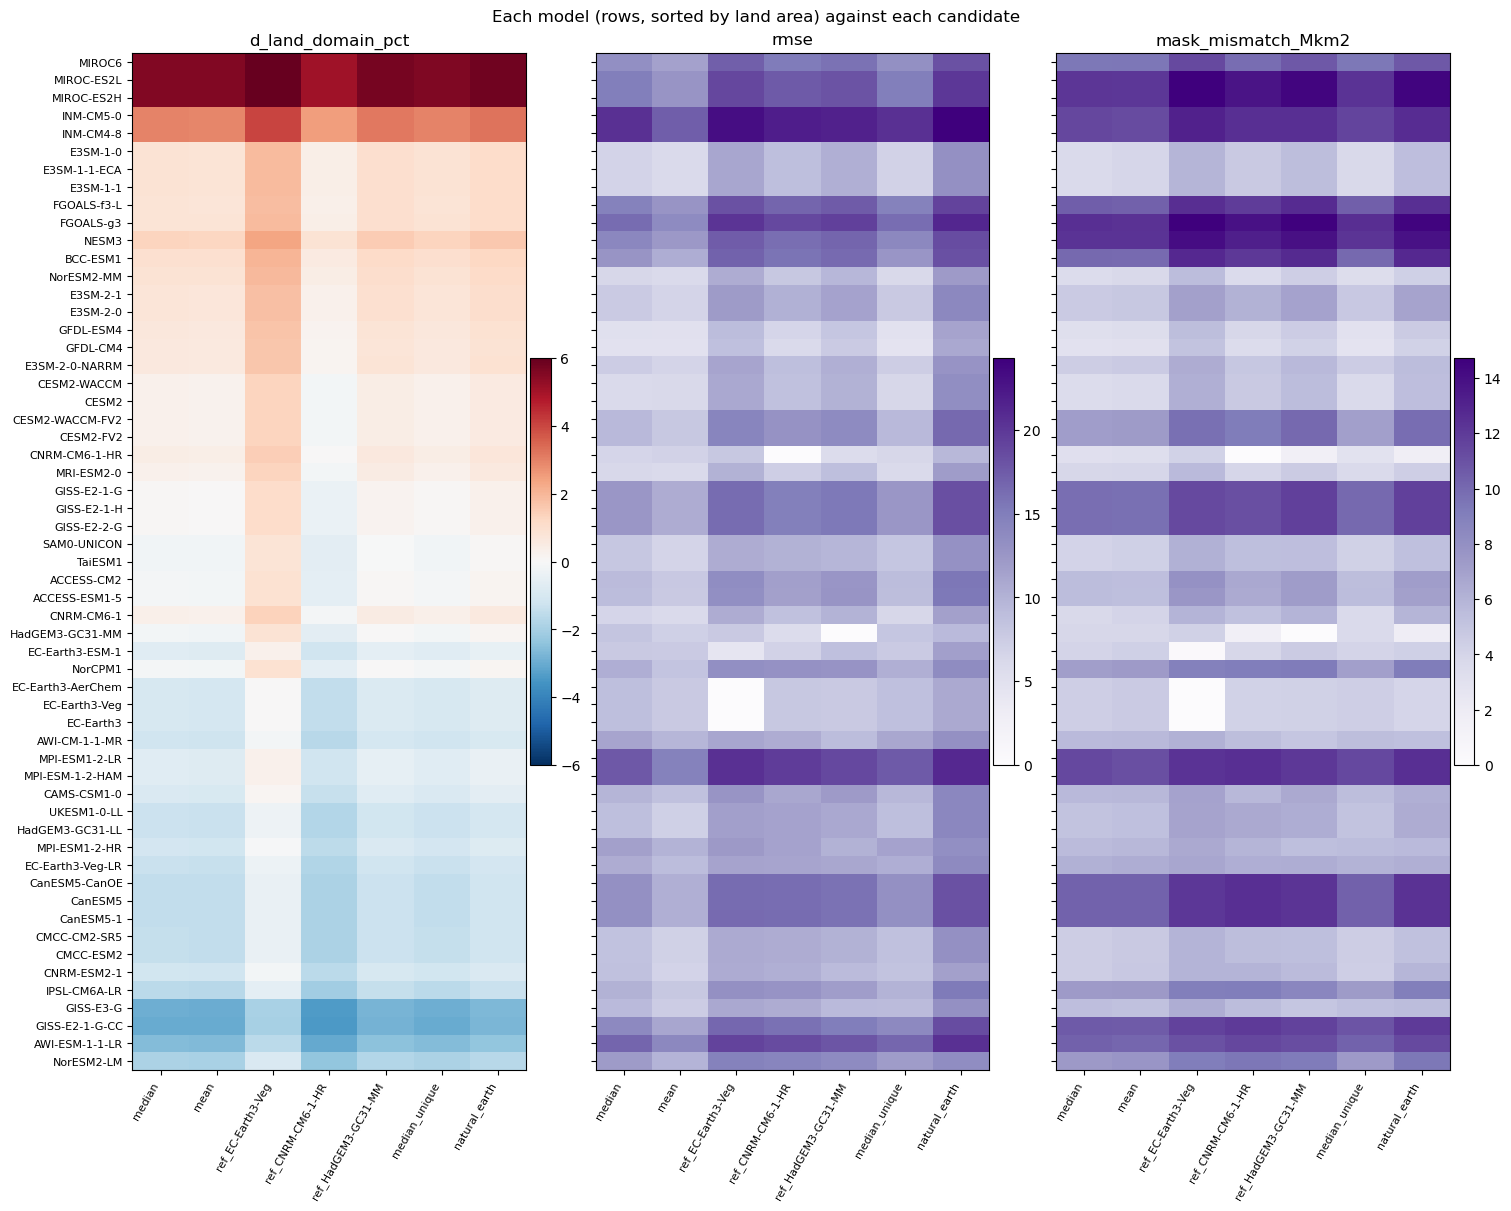

In [81]:
fig, axs = plt.subplots(1, 3, figsize=(15, 12), sharey=True, layout="constrained")
order = info.sort_values("land_Mkm2").index
for ax, metric, cmap, kw in zip(
    axs, ["d_land_domain_pct", "rmse", "mask_mismatch_Mkm2"], ["RdBu_r", "Purples", "Purples"],
    [{"vmin": -6, "vmax": 6}, {"vmin": 0}, {"vmin": 0}],
):
    tab = scores[metric].unstack("candidate").loc[order, list(compare)]
    im = ax.pcolormesh(tab.values, cmap=cmap, **kw)
    ax.set_xticks(np.arange(len(compare)) + 0.5, list(compare), rotation=60, ha="right", fontsize=8)
    ax.set_yticks(np.arange(len(order)) + 0.5, order, fontsize=8)
    ax.set_title(metric)
    fig.colorbar(im, ax=ax, shrink=0.4, pad=0.01)
fig.suptitle("Each model (rows, sorted by land area) against each candidate");

### Zonal land area

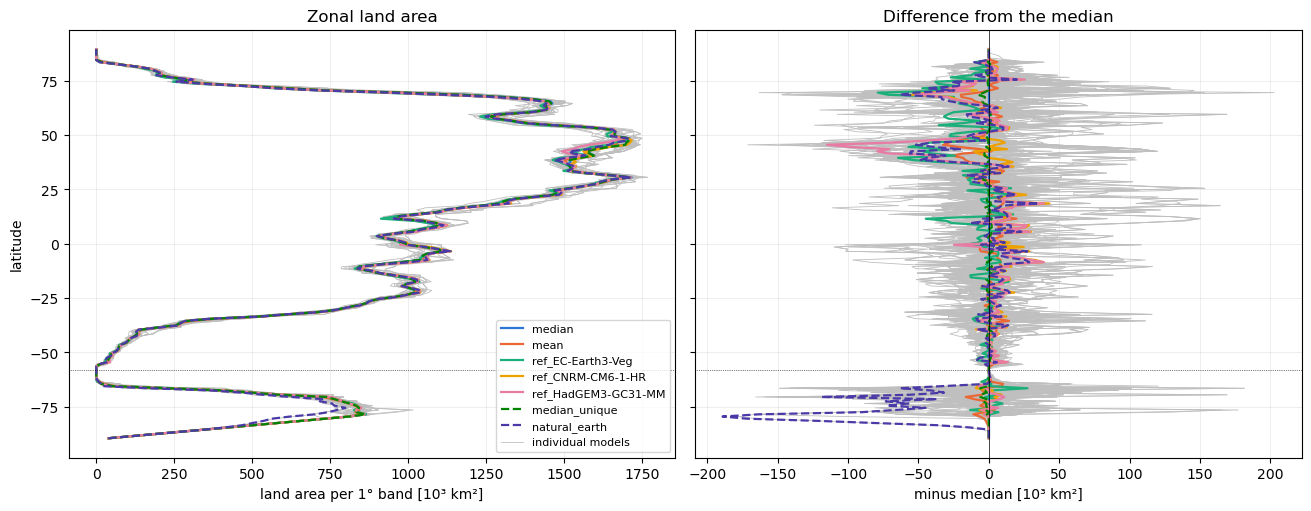

In [82]:
zonal = (lf / 100 * area).sum("lon") / 1e9          # [10^3 km2] per 1° band
zonal_c = (cand / 100 * area).sum("lon") / 1e9

fig, axs = plt.subplots(1, 2, figsize=(13, 5), sharey=True, layout="constrained")
for sid in sids:
    axs[0].plot(zonal.sel(source_id=sid), zonal["lat"], color="0.75", lw=0.6)
    axs[1].plot(zonal.sel(source_id=sid) - zonal_c.sel(candidate="median"), zonal["lat"], color="0.75", lw=0.6)
for name in compare:
    ls = "--" if name in benchmarks else "-"
    axs[0].plot(zonal_c.sel(candidate=name), zonal["lat"], color=colors[name], lw=1.6, ls=ls, label=name)
    axs[1].plot(zonal_c.sel(candidate=name) - zonal_c.sel(candidate="median"), zonal["lat"], color=colors[name], lw=1.6, ls=ls)
axs[0].plot([], [], color="0.75", lw=0.6, label="individual models")
axs[0].set(xlabel="land area per 1° band [10³ km²]", ylabel="latitude", title="Zonal land area")
axs[1].set(xlabel="minus median [10³ km²]", title="Difference from the median")
axs[1].axvline(0, color="k", lw=0.5)
for ax in axs:
    ax.axhline(config.LAT_BNDS.start, color="k", lw=0.5, ls=":")
    ax.grid(alpha=0.3, lw=0.5)
axs[0].legend(fontsize=8, loc="lower right");

### Land area per model

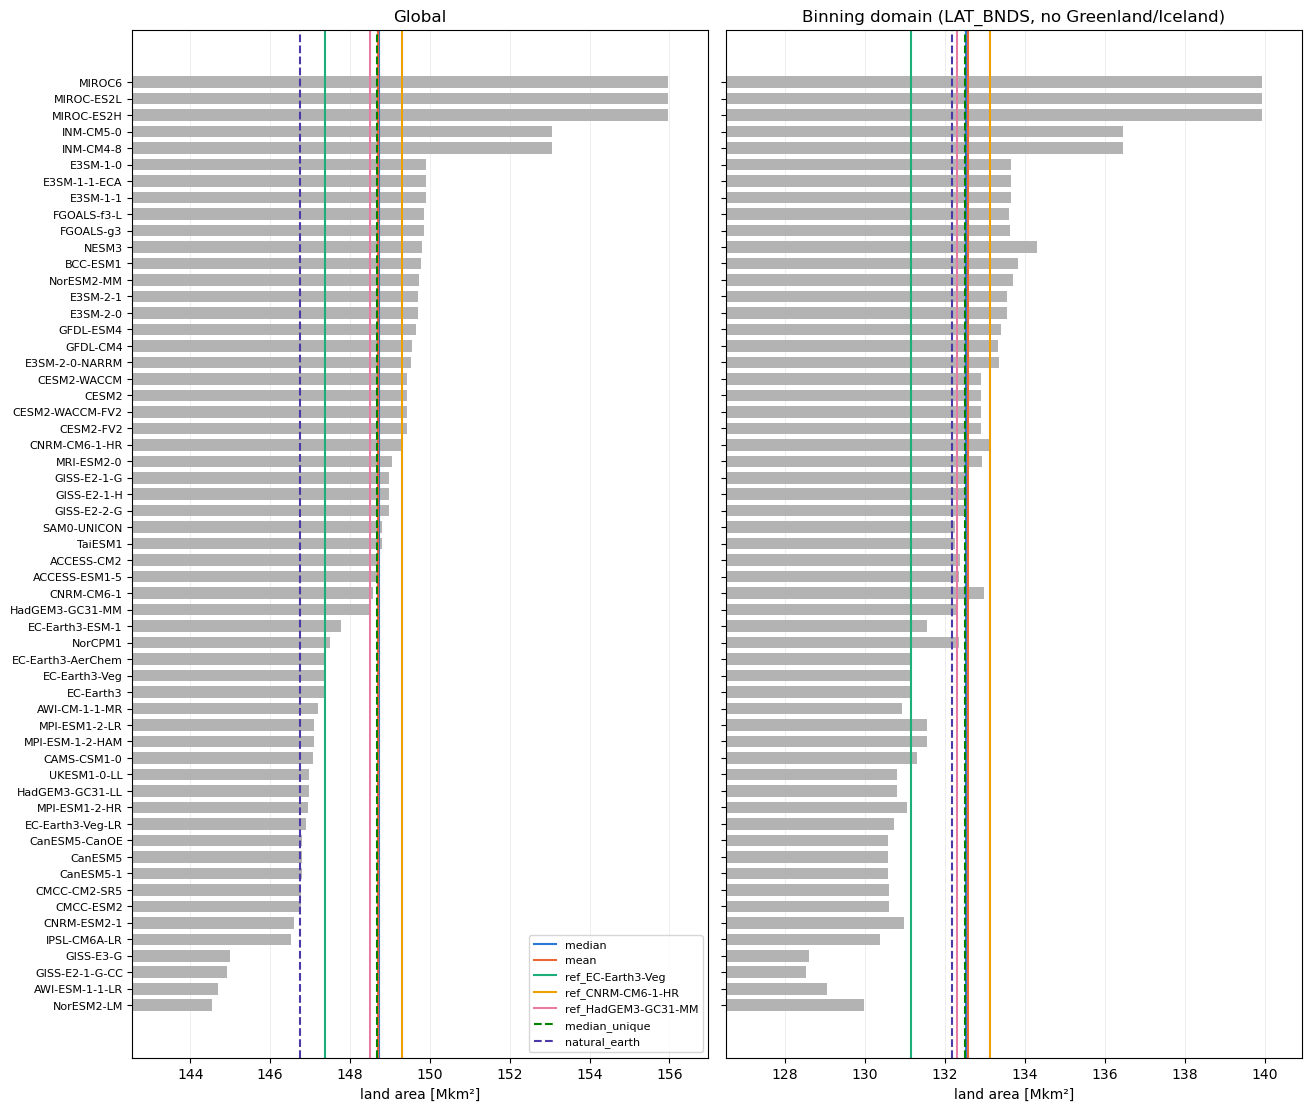

In [83]:
fig, axs = plt.subplots(1, 2, figsize=(13, 11), sharey=True, layout="constrained")
for ax, col, ccol, title in zip(axs, ["land_Mkm2", "land_domain_Mkm2"], ["land_Mkm2", "land_domain_Mkm2"],
                                ["Global", "Binning domain (LAT_BNDS, no Greenland/Iceland)"]):
    vals = info.loc[order, col]
    ax.barh(np.arange(len(order)), vals, color="0.7", height=0.7)
    for name in compare:
        ax.axvline(summary.loc[name, ccol], color=colors[name], lw=1.5, ls="--" if name in benchmarks else "-", label=name)
    ax.set_xlim(vals.min() - 2, vals.max() + 1)
    ax.set_yticks(np.arange(len(order)), order, fontsize=8)
    ax.set(xlabel="land area [Mkm²]", title=title)
    ax.grid(axis="x", alpha=0.3, lw=0.5)
axs[0].legend(fontsize=8, loc="lower right");

### Binary mask area vs threshold

The binning pipeline uses a binary mask (`sftlf > LF_THRESH`), whose area depends on the threshold and on how fractional
the coastlines are. Fractional land area for reference (dots at the right).

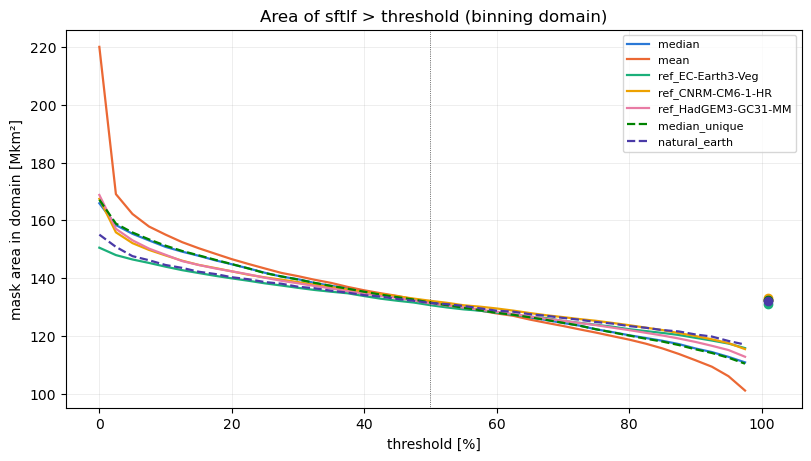

In [84]:
thresholds = np.arange(0, 100, 2.5)
fig, ax = plt.subplots(figsize=(8, 4.5), layout="constrained")
for name in compare:
    a_thr = [float(area.where((cand.sel(candidate=name) > t) & domain).sum()) / 1e12 for t in thresholds]
    ax.plot(thresholds, a_thr, color=colors[name], lw=1.6, ls="--" if name in benchmarks else "-", label=name)
    ax.plot(101, summary.loc[name, "land_domain_Mkm2"], "o", color=colors[name], ms=6)
ax.axvline(LF_THRESH, color="k", lw=0.5, ls=":")
ax.set(xlabel="threshold [%]", ylabel="mask area in domain [Mkm²]", title="Area of sftlf > threshold (binning domain)")
ax.grid(alpha=0.3, lw=0.5)
ax.legend(fontsize=8);

## 7. Spatial averages for three models

Land means of the 1995–2014 climatology of `evspsbl` [W/m²] and `lai` for a coarse (CanESM5, ~2.8°), a medium
(CESM2, ~1°) and a fine (CNRM-CM6-1-HR, ~0.5°) native grid, top member.

* **Truth**: native field, weights `areacella × sftlf` (the model's own land area).
* **1° fields**: `here` = native climatology conservatively regridded with the same regridder as its `sftlf`
  (`skipna=True, na_thres=1.0`, so partly-NaN coastal cells keep their valid fraction), and `file` = the existing
  `regrid_cmip_esgf.py` output in `REGRID_ROOT` (`skipna=False`).
* **1° weights**: cell area × land fraction, with the model's own regridded `sftlf`, each candidate, or Natural Earth;
  `fractional` uses `sftlf/100`, `binary` uses `sftlf > LF_THRESH`.

`d_pct` is the difference from the native truth for the same domain. `covered_Mkm2` is the weighted land area where the
field is valid, so it shows land lost to NaNs.

In [108]:
loader = CMIPESGFLoader(EV_CATALOG)
raw = loader.load_data(TEST_VARS, "historical", source_id=TEST_SIDS, member_id="top", time_slice=TIME_SLICE, verbose=False)


def climatology(da: xr.DataArray, var: str) -> xr.DataArray:
    return units.convert_units(var, da.mean("time")).load()


clim_native, clim_file = {}, {}
for sid in TEST_SIDS:
    print(sid)
    for var in TEST_VARS:
        da = raw[sid][var]
        mid = str(da["member_id"].values[0])
        nat = climatology(da.isel(member=0).sortby("lat"), var)
        assert np.allclose(nat["lat"], native[sid]["lat"], atol=1e-3) and np.allclose(nat["lon"], native[sid]["lon"], atol=1e-3), (sid, var)
        clim_native[sid, var] = nat.assign_coords(lat=native[sid]["lat"], lon=native[sid]["lon"])

        paths = REGRID_ROOT.glob(f"{sid}/{EXPERIMENT_ID}/*/{var}/{var}_*_topmember_gr1deg_*.nc")
        if len(list(paths)) > 0:
            path = next(paths)
            f = xr.open_dataset(path)[var]
        else:
            path = Path(f"{var}_*_{sid}_*_topmember_gr1deg_*.nc")
            f = regridders[sid](da, skipna=True, na_thres=1.0)
        
        fmid = str(f["member_id"].values[0]) if "member_id" in f.coords else "?"
        f = f.isel(member=0) if "member" in f.dims else f
        rg.check_same_grid(f, GRID, label=path.name)
        clim_file[sid, var] = climatology(f.sel(time=TIME_SLICE), var).assign_coords(lat=GRID["lat"], lon=GRID["lon"])
        print(f"{sid:14} {var:8} member {mid} (file {fmid}), {path.name}")

only selecting top member_id
CanESM5
CanESM5        evspsbl  member r1i1p1f1 (file r1i1p1f1), evspsbl_*_CanESM5_*_topmember_gr1deg_*.nc
CanESM5        lai      member r1i1p1f1 (file r1i1p1f1), lai_*_CanESM5_*_topmember_gr1deg_*.nc
CESM2
CESM2          evspsbl  member r1i1p1f1 (file r1i1p1f1), evspsbl_*_CESM2_*_topmember_gr1deg_*.nc
CESM2          lai      member r1i1p1f1 (file r1i1p1f1), lai_*_CESM2_*_topmember_gr1deg_*.nc
CNRM-CM6-1-HR
CNRM-CM6-1-HR  evspsbl  member r1i1p1f2 (file r1i1p1f2), evspsbl_*_CNRM-CM6-1-HR_*_topmember_gr1deg_*.nc
CNRM-CM6-1-HR  lai      member r1i1p1f2 (file r1i1p1f2), lai_*_CNRM-CM6-1-HR_*_topmember_gr1deg_*.nc


In [111]:
weights_1deg = {"own sftlf": None, **compare}
rows = []
for sid in TEST_SIDS:
    nat_lf = native[sid]
    nat_area = native_area.get(sid, grid_area(grids[sid]))
    nat_dom = analysis_domain(nat_lf)
    for var in TEST_VARS:
        nat = clim_native[sid, var]
        for kind, w in [("fractional", nat_area * nat_lf / 100), ("binary", nat_area * (nat_lf > LF_THRESH))]:
            for dname, dmask in [("global", True), ("domain", nat_dom)]:
                ww = w.where(dmask, 0)
                rows.append({"source_id": sid, "var": var, "field": "native", "weights": "own sftlf", "kind": kind,
                             "domain": dname, "value": wmean(nat, ww),
                             "covered_Mkm2": float(ww.where(nat.notnull(), 0).sum()) / 1e12})
        fields = {
            "here": regridders[sid](nat, skipna=True, na_thres=1.0),
            "file": clim_file[sid, var],
        }
        for fname, fld in fields.items():
            for wname, lfw in weights_1deg.items():
                lfw = lf.sel(source_id=sid) if lfw is None else lfw
                for kind, w in [("fractional", area * lfw / 100), ("binary", area * (lfw > LF_THRESH))]:
                    for dname, dmask in [("global", True), ("domain", domain)]:
                        ww = w.where(dmask, 0)
                        rows.append({"source_id": sid, "var": var, "field": fname, "weights": wname, "kind": kind,
                                     "domain": dname, "value": wmean(fld, ww),
                                     "covered_Mkm2": float(ww.where(fld.notnull(), 0).sum()) / 1e12})

avg = pd.DataFrame(rows)
truth_tab = avg[(avg.field == "native") & (avg.kind == "fractional")].set_index(["source_id", "var", "domain"])["value"]
avg = avg.join(truth_tab.rename("truth"), on=["source_id", "var", "domain"])
avg["d_pct"] = 100 * (avg["value"] / avg["truth"] - 1)
print("Native truth (areacella x sftlf):")
truth_tab.unstack("domain").round(3)

Native truth (areacella x sftlf):


domain                 domain  global
source_id     var                    
CESM2         evspsbl  42.163  37.715
              lai       1.571   1.398
CNRM-CM6-1-HR evspsbl  41.019  36.904
              lai       1.738   1.550
CanESM5       evspsbl  48.650  43.557
              lai       1.533   1.364

Difference from the native truth [%], binning domain:

In [112]:
def pivot(var: str, domain_name: str, col: str = "d_pct") -> pd.DataFrame:
    sub = avg[(avg["var"] == var) & (avg["domain"] == domain_name)]
    tab = sub.pivot_table(index=["field", "kind", "weights"], columns="source_id", values=col, sort=False)
    return tab[TEST_SIDS]


for var in TEST_VARS:
    print(f"\n=== {var}: d_pct, binning domain ===")
    display(pivot(var, "domain").round(2))


=== evspsbl: d_pct, binning domain ===


source_id                              CanESM5  CESM2  CNRM-CM6-1-HR
field  kind       weights                                           
native fractional own sftlf               0.00   0.00           0.00
       binary     own sftlf              -3.33  -1.31          -1.10
here   fractional own sftlf               1.40   2.13           2.13
                  median                  1.17   2.40           2.38
                  mean                    1.89   3.71           3.70
                  ref_EC-Earth3-Veg       1.16   1.71           1.06
                  ref_CNRM-CM6-1-HR       2.01   2.83           2.13
                  ref_HadGEM3-GC31-MM     1.86   2.72           1.93
                  median_unique           1.23   2.50           2.43
                  natural_earth           1.59   2.12           1.26
       binary     own sftlf              -2.95  -0.47          -0.24
                  median                 -0.50  -0.43          -0.73
                  mean                   -0.54  -0.42          -0.68
                  ref_EC-Earth3-Veg       0.50   0.51          -0.43
                  ref_CNRM-CM6-1-HR       0.56   0.60          -0.24
                  ref_HadGEM3-GC31-MM     0.24   0.22          -0.77
                  median_unique          -0.47  -0.39          -0.72
                  natural_earth           0.41   0.37          -0.62
file   fractional own sftlf               1.40   2.13           2.13
                  median                  1.17   2.40           2.38
                  mean                    1.89   3.71           3.70
                  ref_EC-Earth3-Veg       1.16   1.71           1.06
                  ref_CNRM-CM6-1-HR       2.01   2.83           2.13
                  ref_HadGEM3-GC31-MM     1.86   2.72           1.93
                  median_unique           1.23   2.50           2.43
                  natural_earth           1.59   2.12           1.26
       binary     own sftlf              -2.95  -0.47          -0.24
                  median                 -0.50  -0.43          -0.73
                  mean                   -0.54  -0.42          -0.68
                  ref_EC-Earth3-Veg       0.50   0.51          -0.43
                  ref_CNRM-CM6-1-HR       0.56   0.60          -0.24
                  ref_HadGEM3-GC31-MM     0.24   0.22          -0.77
                  median_unique          -0.47  -0.39          -0.72
                  natural_earth           0.41   0.37          -0.62


=== lai: d_pct, binning domain ===


source_id                              CanESM5  CESM2  CNRM-CM6-1-HR
field  kind       weights                                           
native fractional own sftlf               0.00   0.00           0.00
       binary     own sftlf              -1.71  -0.46          -0.19
here   fractional own sftlf              -0.91   0.27          -0.08
                  median                 -1.10   0.35          -0.69
                  mean                   -1.11   0.71          -0.51
                  ref_EC-Earth3-Veg      -0.48   0.87          -0.18
                  ref_CNRM-CM6-1-HR      -0.63   0.81          -0.08
                  ref_HadGEM3-GC31-MM    -0.50   1.27           0.02
                  median_unique          -1.06   0.40          -0.64
                  natural_earth          -0.36   0.99           0.03
       binary     own sftlf              -2.60  -0.83          -0.81
                  median                 -1.57  -0.68          -1.23
                  mean                   -1.62  -0.68          -1.31
                  ref_EC-Earth3-Veg      -0.59   0.45          -0.36
                  ref_CNRM-CM6-1-HR      -1.00  -0.14          -0.81
                  ref_HadGEM3-GC31-MM    -0.88   0.35          -0.65
                  median_unique          -1.49  -0.61          -1.19
                  natural_earth          -0.59   0.36          -0.47
file   fractional own sftlf              -0.91   0.27          -0.08
                  median                 -1.10   0.35          -0.69
                  mean                   -1.11   0.71          -0.51
                  ref_EC-Earth3-Veg      -0.48   0.87          -0.18
                  ref_CNRM-CM6-1-HR      -0.63   0.81          -0.08
                  ref_HadGEM3-GC31-MM    -0.50   1.27           0.02
                  median_unique          -1.06   0.40          -0.64
                  natural_earth          -0.36   0.99           0.03
       binary     own sftlf              -2.60  -0.83          -0.81
                  median                 -1.57  -0.68          -1.23
                  mean                   -1.62  -0.68          -1.31
                  ref_EC-Earth3-Veg      -0.59   0.45          -0.36
                  ref_CNRM-CM6-1-HR      -1.00  -0.14          -0.81
                  ref_HadGEM3-GC31-MM    -0.88   0.35          -0.65
                  median_unique          -1.49  -0.61          -1.19
                  natural_earth          -0.59   0.36          -0.47

In [106]:
for var in TEST_VARS:
    print(f"\n=== {var}: d_pct, global ===")
    display(pivot(var, "global").round(2))
print("\n=== lai: land area covered by valid data [Mkm2], binning domain ===")
display(pivot("lai", "domain", "covered_Mkm2").round(2))


=== evspsbl: d_pct, global ===


source_id                              CanESM5  CESM2  CNRM-CM6-1-HR
field  kind       weights                                           
native fractional own sftlf               0.00   0.00           0.00
       binary     own sftlf              -3.30  -1.32          -1.16
here   fractional own sftlf               1.42   2.17           2.18
                  median                  1.36   2.60           2.40
                  mean                    2.13   3.98           3.79
                  ref_EC-Earth3-Veg       1.23   1.77           0.96
                  ref_CNRM-CM6-1-HR       2.24   3.07           2.18
                  ref_HadGEM3-GC31-MM     2.02   2.88           1.91
                  median_unique           1.44   2.72           2.47
                  natural_earth           2.76   3.29           2.14
       binary     own sftlf              -2.91  -0.51          -0.28
                  median                 -0.41  -0.36          -0.82
                  mean                   -0.42  -0.31          -0.74
                  ref_EC-Earth3-Veg       0.50   0.48          -0.61
                  ref_CNRM-CM6-1-HR       0.75   0.76          -0.28
                  ref_HadGEM3-GC31-MM     0.34   0.29          -0.89
                  median_unique          -0.35  -0.29          -0.79
                  natural_earth           1.52   1.47           0.18
file   fractional own sftlf               1.42   2.17           2.18
                  median                  1.36   2.60           2.40
                  mean                    2.13   3.98           3.79
                  ref_EC-Earth3-Veg       1.23   1.77           0.96
                  ref_CNRM-CM6-1-HR       2.24   3.07           2.18
                  ref_HadGEM3-GC31-MM     2.02   2.88           1.91
                  median_unique           1.44   2.72           2.47
                  natural_earth           2.76   3.29           2.14
       binary     own sftlf              -2.91  -0.51          -0.28
                  median                 -0.41  -0.36          -0.82
                  mean                   -0.42  -0.31          -0.74
                  ref_EC-Earth3-Veg       0.50   0.48          -0.61
                  ref_CNRM-CM6-1-HR       0.75   0.76          -0.28
                  ref_HadGEM3-GC31-MM     0.34   0.29          -0.89
                  median_unique          -0.35  -0.29          -0.79
                  natural_earth           1.52   1.47           0.18


=== lai: d_pct, global ===


source_id                              CanESM5  CESM2  CNRM-CM6-1-HR
field  kind       weights                                           
native fractional own sftlf               0.00   0.00           0.00
       binary     own sftlf              -1.61  -0.45          -0.24
here   fractional own sftlf              -0.91   0.27          -0.07
                  median                 -0.92   0.55          -0.73
                  mean                   -0.88   0.95          -0.51
                  ref_EC-Earth3-Veg      -0.42   0.95          -0.35
                  ref_CNRM-CM6-1-HR      -0.39   1.04          -0.07
                  ref_HadGEM3-GC31-MM    -0.34   1.42          -0.04
                  median_unique          -0.85   0.63          -0.66
                  natural_earth           0.90   2.26           1.07
       binary     own sftlf              -2.51  -0.87          -0.83
                  median                 -1.45  -0.55          -1.34
                  mean                   -1.47  -0.52          -1.39
                  ref_EC-Earth3-Veg      -0.60   0.45          -0.61
                  ref_CNRM-CM6-1-HR      -0.79   0.07          -0.83
                  ref_HadGEM3-GC31-MM    -0.78   0.46          -0.77
                  median_unique          -1.34  -0.45          -1.27
                  natural_earth           0.64   1.61           0.54
file   fractional own sftlf              -0.91  -1.49          -2.12
                  median                 -0.92  -1.23          -2.50
                  mean                   -0.88  -1.05          -2.47
                  ref_EC-Earth3-Veg      -0.42  -0.40          -2.10
                  ref_CNRM-CM6-1-HR      -0.39  -0.55          -2.12
                  ref_HadGEM3-GC31-MM    -0.34  -0.26          -2.22
                  median_unique          -0.85  -1.17          -2.47
                  natural_earth           0.90   0.77          -1.07
       binary     own sftlf              -2.51  -1.59          -2.13
                  median                 -1.45  -1.10          -2.29
                  mean                   -1.47  -1.13          -2.31
                  ref_EC-Earth3-Veg      -0.60  -0.31          -2.04
                  ref_CNRM-CM6-1-HR      -0.79  -0.69          -2.13
                  ref_HadGEM3-GC31-MM    -0.78  -0.41          -2.17
                  median_unique          -1.34  -1.05          -2.26
                  natural_earth           0.64   0.66          -0.97


=== lai: land area covered by valid data [Mkm2], binning domain ===


source_id                              CanESM5   CESM2  CNRM-CM6-1-HR
field  kind       weights                                            
native fractional own sftlf             130.59  132.90         132.90
       binary     own sftlf             128.73  132.56         132.34
here   fractional own sftlf             130.58  132.89         133.09
                  median                132.52  132.35         132.37
                  mean                  132.57  131.85         131.92
                  ref_EC-Earth3-Veg     131.16  131.10         131.15
                  ref_CNRM-CM6-1-HR     133.13  132.71         133.09
                  ref_HadGEM3-GC31-MM   132.30  131.87         132.26
                  median_unique         132.52  132.31         132.36
                  natural_earth         132.17  131.86         132.15
       binary     own sftlf             128.55  132.04         132.08
                  median                131.53  131.53         131.49
                  mean                  131.61  131.61         131.57
                  ref_EC-Earth3-Veg     130.60  130.59         130.60
                  ref_CNRM-CM6-1-HR     132.12  132.11         132.08
                  ref_HadGEM3-GC31-MM   131.25  131.25         131.25
                  median_unique         131.50  131.50         131.46
                  natural_earth         131.36  131.35         131.36
file   fractional own sftlf             130.58  127.41         125.32
                  median                132.52  127.00         124.13
                  mean                  132.57  125.72         122.98
                  ref_EC-Earth3-Veg     131.16  126.96         124.69
                  ref_CNRM-CM6-1-HR     133.13  127.99         125.32
                  ref_HadGEM3-GC31-MM   132.30  127.05         124.82
                  median_unique         132.52  126.95         124.09
                  natural_earth         132.17  127.64         125.41
       binary     own sftlf             128.55  129.12         126.89
                  median                131.53  129.05         126.61
                  mean                  131.61  129.07         126.61
                  ref_EC-Earth3-Veg     130.60  127.91         125.90
                  ref_CNRM-CM6-1-HR     132.12  129.23         126.89
                  ref_HadGEM3-GC31-MM   131.25  128.36         126.58
                  median_unique         131.50  129.03         126.63
                  natural_earth         131.36  128.50         126.74

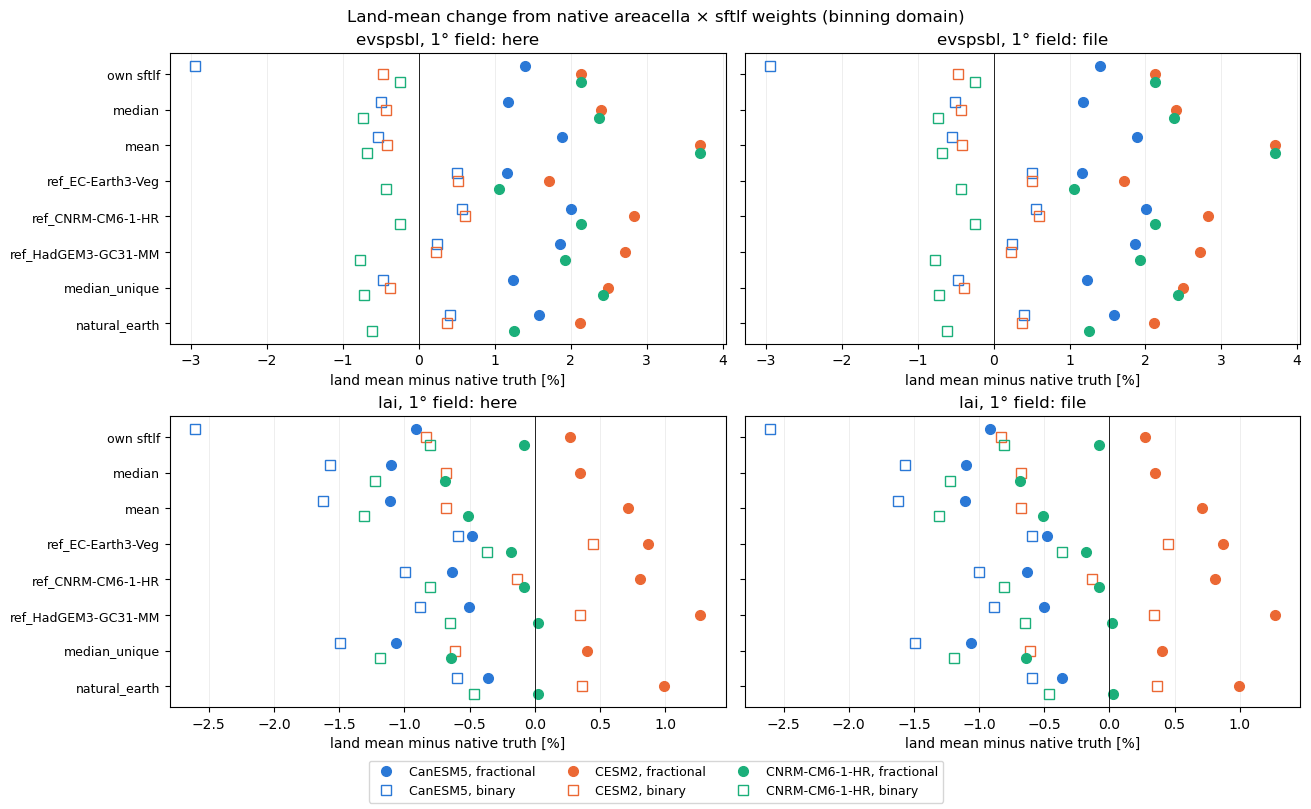

In [113]:
wnames = ["own sftlf", *compare]
fig, axs = plt.subplots(2, 2, figsize=(13, 8), sharey=True, layout="constrained")
for (i, var), (j, fname) in [((i, v), (j, f)) for i, v in enumerate(TEST_VARS) for j, f in enumerate(["here", "file"])]:
    ax = axs[i, j]
    for k, sid in enumerate(TEST_SIDS):
        for kind, marker, fill in [("fractional", "o", SERIES[k]), ("binary", "s", "none")]:
            sub = avg[(avg["var"] == var) & (avg.field == fname) & (avg.kind == kind) & (avg.domain == "domain") & (avg.source_id == sid)]
            sub = sub.set_index("weights").loc[wnames]
            y = np.arange(len(wnames)) + (k - 1) * 0.22
            ax.plot(sub["d_pct"], y, marker, ms=7, mec=SERIES[k], mfc=fill, ls="none",
                    label=f"{sid}, {kind}" if (i, j) == (0, 0) else None)
    ax.axvline(0, color="k", lw=0.6)
    ax.set_yticks(np.arange(len(wnames)), wnames, fontsize=9)
    ax.set(title=f"{var}, 1° field: {fname}", xlabel="land mean minus native truth [%]")
    ax.grid(axis="x", alpha=0.3, lw=0.5)
axs[0, 0].invert_yaxis()
fig.legend(loc="outside lower center", ncols=3, fontsize=9)
fig.suptitle("Land-mean change from native areacella × sftlf weights (binning domain)");

## 8. Write the 1° grid file

`OUT_DIR/grid_1deg.nc` holds the cell area and the candidate land fractions (`sftlf_<candidate>`).
`sftlf` itself is written only once `SFTLF_CHOICE` is set. The per-model regridded fields go to
`OUT_DIR/sftlf_cmip6_by_model_1deg.nc`.

In [115]:
OUT_DIR.mkdir(parents=True, exist_ok=True)
lat_bnds = np.stack([GRID["lat_b"].values[:-1], GRID["lat_b"].values[1:]], axis=1)
lon_bnds = np.stack([GRID["lon_b"].values[:-1], GRID["lon_b"].values[1:]], axis=1)

out = xr.Dataset(
    {"areacella": area},
    coords={"lat": GRID["lat"], "lon": GRID["lon"]},
)
out["lat_bnds"] = (("lat", "nv"), lat_bnds)
out["lon_bnds"] = (("lon", "nv"), lon_bnds)
out["lat"].attrs["bounds"] = "lat_bnds"
out["lon"].attrs["bounds"] = "lon_bnds"
for name, da in candidates.items():
    out[f"sftlf_{name}"] = da.astype("float32")
    out[f"sftlf_{name}"].attrs = {"standard_name": "land_area_fraction", "units": "%",
                                  "long_name": f"land area fraction ({name} of conservatively regridded CMIP6 sftlf)"}
if SFTLF_CHOICE is not None:
    out["sftlf"] = out[f"sftlf_{SFTLF_CHOICE}"].copy()
    out["sftlf"].attrs["candidate"] = SFTLF_CHOICE
out.attrs = {
    "title": f"Cell area and land area fraction on the common {rg.grid_tag(RES)} grid (regrid.target_grid)",
    "source_ids": ", ".join(sids),
    "sftlf_sources": "cmip6_all.csv fx files, historical preferred",
    "regridding": "xESMF first-order conservative from each native grid (regrid.make_regridder)",
    "notebook": "check-cmip-grids.ipynb",
    "created": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M"),
}
out.to_netcdf(OUT_DIR / f"grid_{rg.grid_tag(RES)}.nc")

lf.astype("float32").assign_coords(source_id=np.asarray(sids, dtype="U")).to_dataset(name="sftlf").assign_attrs(out.attrs).to_netcdf(OUT_DIR / f"sftlf_cmip6_by_model_{rg.grid_tag(RES)}.nc")
print(xr.open_dataset(OUT_DIR / f"grid_{rg.grid_tag(RES)}.nc"))
print(OUT_DIR / f"grid_{rg.grid_tag(RES)}.nc")

<xarray.Dataset> Size: 2MB
Dimensions:                    (lat: 180, lon: 360, nv: 2)
Coordinates:
  * lat                        (lat) float64 1kB -89.5 -88.5 -87.5 ... 88.5 89.5
  * lon                        (lon) float64 3kB -179.5 -178.5 ... 178.5 179.5
Dimensions without coordinates: nv
Data variables:
    areacella                  (lat, lon) float64 518kB ...
    lat_bnds                   (lat, nv) float64 3kB ...
    lon_bnds                   (lon, nv) float64 6kB ...
    sftlf_median               (lat, lon) float32 259kB ...
    sftlf_mean                 (lat, lon) float32 259kB ...
    sftlf_ref_EC-Earth3-Veg    (lat, lon) float32 259kB ...
    sftlf_ref_CNRM-CM6-1-HR    (lat, lon) float32 259kB ...
    sftlf_ref_HadGEM3-GC31-MM  (lat, lon) float32 259kB ...
Attributes:
    title:          Cell area and land area fraction on the common 1deg grid ...
    source_ids:     ACCESS-CM2, ACCESS-ESM1-5, AWI-CM-1-1-MR, AWI-ESM-1-1-LR,...
    sftlf_sources:  cmip6_all.csv fx files

## Findings (run of 2026-10-07)

**Coverage.** 58 of the 74 models in the ET catalog have `sftlf` (16 do not, including both UKESM1 models, BCC-CSM2-MR and
GFDL-CM4). With ICON-ESM-LR excluded, 57 models are on the 1° grid, and they hold only 40 distinct fields because model
families share land masks (E3SM, CESM2, GISS, CanESM5, EC-Earth3, ...).

**Native data problems.**
* `areacella`: some EC-Earth3, EC-Earth3-AerChem, EC-Earth3-Veg and EC-Earth3-Veg-LR members sum to 10% of the sphere
  (other members are fine), MCM-UA-1-0 sums to 1% (units), and CMCC-CM2-HR4 and FGOALS-f3-L have none on their `sftlf` grid.
  The valid files imply radii of 6370–6371.25 km (≤ 0.04% in area). A single analytic 1° area avoids all of this. It
  matches E3SM's 1° `areacella` to 5e-5 after rescaling the radius.
* `sftlf` is not always the same across a model's files. The EC-Earth3 family has two mask versions that differ by member,
  and FGOALS-g3's `amip` mask differs from its `historical` one. The `historical` file is used here.
* Eight models (AWI, MPI-ESM, INM) have binary 0/100 coastlines.

**Native land area** ranges from 144.7 to 156.0 Mkm² (median 148.8). The outliers are MIROC (156.0, +5%), INM (153.1),
AWI-ESM-1-1-LR (144.7), and GISS-E2-1-G-CC and GISS-E3-G (~145, whose `sftlf` is below 100% over much of the continental
interiors). Large lakes (Caspian, Great Lakes, Victoria) are land in some models and water in others. Conservative
regridding to 1° conserves every model's land area to within 0.003%.

**Candidates.**
* `median` (148.72 Mkm²) and `mean` (148.75) are equally close to the ensemble in land area and mask IoU. The mean has the
  lower RMSE, but it spreads small land fractions into 27,560 partial cells (median: 8,398), so its area above low
  thresholds explodes.
* `median_unique` is almost identical to `median` (counting a family once barely matters).
* The single reference models are further from the ensemble than either statistic. EC-Earth3-HR (148.17) is the
  smallest; CNRM-CM6-1-HR (149.31) the largest.
* Natural Earth has less land (146.74) mainly because Antarctic ice shelves are not land there. Inside the binning
  domain it is close to the median (132.17 vs 132.51).

**Spatial averages (binning domain).** The choice among the candidates moves land-mean ET by about 1–2 percentage points.
A larger effect is that *fractional* 1° weights bias `evspsbl` high relative to the native truth, by +1.1 to +3.6%
(+1.4 to +2.1% even with the model's own regridded `sftlf`). The reason: coastal native cells mix in ocean evaporation,
and regridding spreads it. Binary masks (> 50%) bring the median-weighted means to within ±1%. For `lai`, the existing
`regrid_cmip_esgf.py` files (`skipna=False`) lose coastal land: valid land area is 127.4 vs 132.9 Mkm² for CESM2 and
125.3 vs 132.9 for CNRM-CM6-1-HR, biasing the means by −1 to −2%. Regridding with `skipna=True, na_thres=1.0` keeps that
coverage. CanESM5's coarse cells are unaffected.